## 1. Import Required Libraries

These libraries are used for data loading, cleaning, visualization, regression modelling, classification modelling, and evaluation.


In [1]:
# Core libraries
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load Dataset and Assign Column Headers

The dataset does not contain column names in the CSV file, so headers are assigned manually according to the automobile dataset structure.


In [2]:
# Column headers for the automobile dataset
column_names = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location",
    "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
    "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
    "compression-ratio", "horsepower", "peak-rpm", "city-mpg",
    "highway-mpg", "price"
]

# Dataset path options:
# 1. If running in the ChatGPT sandbox, the uploaded dataset is available at /mnt/data/auto.csv.
# 2. If running in Colab/Jupyter, place auto.csv in the same folder as this notebook.
# 3. If the local file is not found, the code loads the IBM cloud dataset URL from the assignment brief.
local_paths = [
    "auto.csv",
    "/content/auto.csv",
    "/mnt/data/auto.csv"
]

dataset_url = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv"
)

data_path = None
for path in local_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is not None:
    df = pd.read_csv(data_path, names=column_names)
    print(f"Dataset loaded from local path: {data_path}")
else:
    df = pd.read_csv(dataset_url, names=column_names)
    print("Dataset loaded from IBM cloud URL.")

# Keep a raw copy before cleaning
df_raw = df.copy()

print("Dataset loaded successfully.")


Dataset loaded from local path: auto.csv
Dataset loaded successfully.


## 3. Display Dataset Shape and First 10 Rows

This step satisfies the brief requirement to display the dataset shape and first 10 rows.


In [3]:
print("Dataset shape:", df.shape)
display(df.head(10))


Dataset shape: (205, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,192.7,71.4,55.7,2844,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,192.7,71.4,55.7,2954,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,192.7,71.4,55.9,3086,ohc,five,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,178.2,67.9,52.0,3053,ohc,five,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


## 4. Initial Dataset Information and Data Types

This step checks the structure of the dataset, columns, non-null values and data types.


In [4]:
print("Dataset information:")
df.info()

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engin

,Data Type
symboling,int64
normalized-losses,object
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


## 5. Replace `?` with Missing Values

The dataset uses `?` to represent missing values. These are replaced with `NaN` so that pandas can process them correctly.


In [5]:
# Replace '?' with NaN
df.replace("?", np.nan, inplace=True)

# Count missing values after replacement
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]

print("Columns containing missing values:")
display(missing_values.to_frame("Missing Values"))


Columns containing missing values:


,Missing Values
normalized-losses,41
stroke,4
price,4
bore,4
horsepower,2
peak-rpm,2
num-of-doors,2


## 6. Convert Required Columns to Numeric Data Types

The brief specifically requires `price` and `horsepower` to be converted to float. Other numeric-looking columns with missing values are also converted for proper analysis.


In [6]:
# Convert numeric-looking columns currently stored as object due to '?' values
numeric_columns_to_convert = [
    "normalized-losses", "bore", "stroke", "horsepower", "peak-rpm", "price"
]

for col in numeric_columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Ensure required columns are float
df["price"] = df["price"].astype(float)
df["horsepower"] = df["horsepower"].astype(float)

print("Updated data types for converted columns:")
display(df[numeric_columns_to_convert].dtypes.to_frame("Data Type"))


Updated data types for converted columns:


,Data Type
normalized-losses,float64
bore,float64
stroke,float64
horsepower,float64
peak-rpm,float64
price,float64


## 7. Handle Missing Values

For modelling, missing values must be treated. The target variable `price` is essential, so rows with missing price are removed. Missing numerical predictors are filled using mean replacement. Missing categorical predictors are filled using mode replacement.


In [7]:
# Drop rows where the target variable price is missing
before_rows = df.shape[0]
df = df.dropna(subset=["price"]).copy()
after_rows = df.shape[0]

print(f"Rows before removing missing price: {before_rows}")
print(f"Rows after removing missing price: {after_rows}")
print(f"Rows removed due to missing target price: {before_rows - after_rows}")

# Identify numerical and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Mean replacement for numerical columns except target price
for col in numeric_cols:
    if col != "price":
        df[col] = df[col].fillna(df[col].mean())

# Mode replacement for categorical columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after cleaning:")
display(df.isnull().sum().to_frame("Missing Values").T)


Rows before removing missing price: 205
Rows after removing missing price: 201
Rows removed due to missing target price: 4

Missing values after cleaning:


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
Missing Values,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 8. Descriptive Statistics

This section calculates mean, median and standard deviation for numerical variables as required in the brief.


In [8]:
# Descriptive statistics: mean, median and standard deviation
descriptive_stats = pd.DataFrame({
    "Mean": df.select_dtypes(include=[np.number]).mean(),
    "Median": df.select_dtypes(include=[np.number]).median(),
    "Standard Deviation": df.select_dtypes(include=[np.number]).std()
}).round(2)

display(descriptive_stats)

# Focused summary for key assignment variables
key_variables = ["price", "horsepower", "engine-size", "city-mpg", "highway-mpg", "curb-weight"]
display(descriptive_stats.loc[key_variables])


,Mean,Median,Standard Deviation
symboling,0.84,1.00,1.25
normalized-losses,122.00,122.00,32.00
wheel-base,98.80,97.00,6.07
length,174.20,173.20,12.32
width,65.89,65.50,2.10
height,53.77,54.10,2.45
curb-weight,2555.67,2414.00,517.30
engine-size,126.88,120.00,41.55
bore,3.33,3.31,0.27
stroke,3.26,3.29,0.32


,Mean,Median,Standard Deviation
price,13207.13,10295.0,7947.07
horsepower,103.40,95.0,37.37
engine-size,126.88,120.0,41.55
city-mpg,25.18,24.0,6.42
highway-mpg,30.69,30.0,6.82
curb-weight,2555.67,2414.0,517.30


## 9. Unique Values in Categorical Columns

This section lists unique values in categorical columns. It helps understand feature categories such as fuel type, body style, engine type and drive wheels.


In [9]:
# Display unique values in each categorical column
for col in categorical_cols:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].unique())



make (22 unique values):
['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan' 'peugot'
 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen'
 'volvo']

fuel-type (2 unique values):
['gas' 'diesel']

aspiration (2 unique values):
['std' 'turbo']

num-of-doors (2 unique values):
['two' 'four']

body-style (5 unique values):
['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']

drive-wheels (3 unique values):
['rwd' 'fwd' '4wd']

engine-location (2 unique values):
['front' 'rear']

engine-type (6 unique values):
['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf']

num-of-cylinders (7 unique values):
['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']

fuel-system (8 unique values):
['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']


## 10. Feature Engineering

The brief requires:

- Creating `city-L/100km = 235 / city-mpg`
- Binning horsepower into Low, Medium and High
- Normalizing at least one feature


In [10]:
# Create city fuel consumption in L/100km
df["city-L/100km"] = 235 / df["city-mpg"]

# Optional additional feature: highway fuel consumption in L/100km
df["highway-L/100km"] = 235 / df["highway-mpg"]

# Horsepower binning: Low, Medium, High
horsepower_bins = np.linspace(df["horsepower"].min(), df["horsepower"].max(), 4)
horsepower_labels = ["Low", "Medium", "High"]

df["horsepower-binned"] = pd.cut(
    df["horsepower"],
    bins=horsepower_bins,
    labels=horsepower_labels,
    include_lowest=True
)

# Normalize at least one feature using Min-Max normalization
df["length-normalized"] = (df["length"] - df["length"].min()) / (df["length"].max() - df["length"].min())

print("Feature engineering completed.")
display(df[["city-mpg", "city-L/100km", "highway-mpg", "highway-L/100km", "horsepower", "horsepower-binned", "length", "length-normalized"]].head(10))


Feature engineering completed.


,city-mpg,city-L/100km,highway-mpg,highway-L/100km,horsepower,horsepower-binned,length,length-normalized
0,21,11.190476,27,8.703704,111.0,Low,168.8,0.413433
1,21,11.190476,27,8.703704,111.0,Low,168.8,0.413433
2,19,12.368421,26,9.038462,154.0,Medium,171.2,0.449254
3,24,9.791667,30,7.833333,102.0,Low,176.6,0.529851
4,18,13.055556,22,10.681818,115.0,Low,176.6,0.529851
5,19,12.368421,25,9.400000,110.0,Low,177.3,0.540299
6,19,12.368421,25,9.400000,110.0,Low,192.7,0.770149
7,19,12.368421,25,9.400000,110.0,Low,192.7,0.770149
8,17,13.823529,20,11.750000,140.0,Medium,192.7,0.770149
10,23,10.217391,29,8.103448,101.0,Low,176.8,0.532836


## 11. EDA Visualization 1: Histogram of Price

This histogram shows the distribution of car prices.


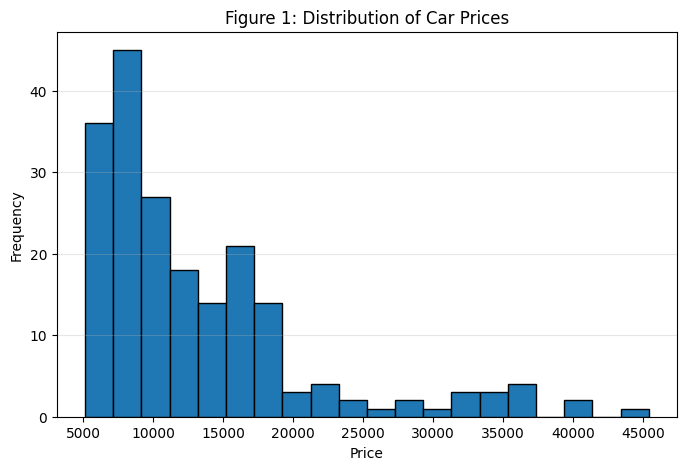

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=20, edgecolor="black")
plt.title("Figure 1: Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 12. EDA Visualization 2: Histogram of Horsepower

This histogram shows the distribution of horsepower values.


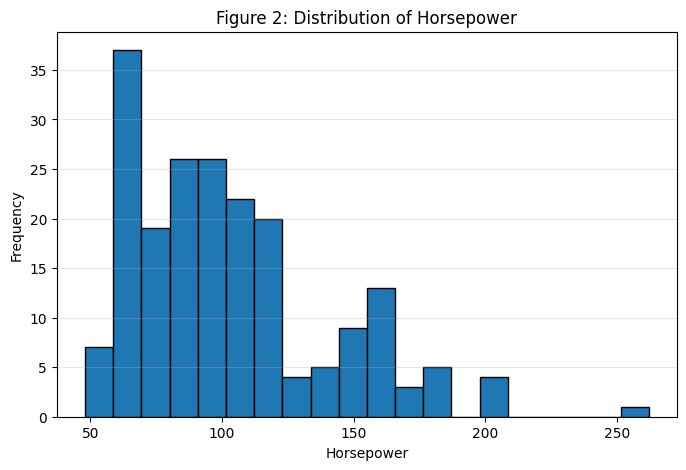

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df["horsepower"], bins=20, edgecolor="black")
plt.title("Figure 2: Distribution of Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 13. EDA Visualization 3: Boxplot of Price by Body Style

This boxplot helps identify price variation and outliers across different body styles.


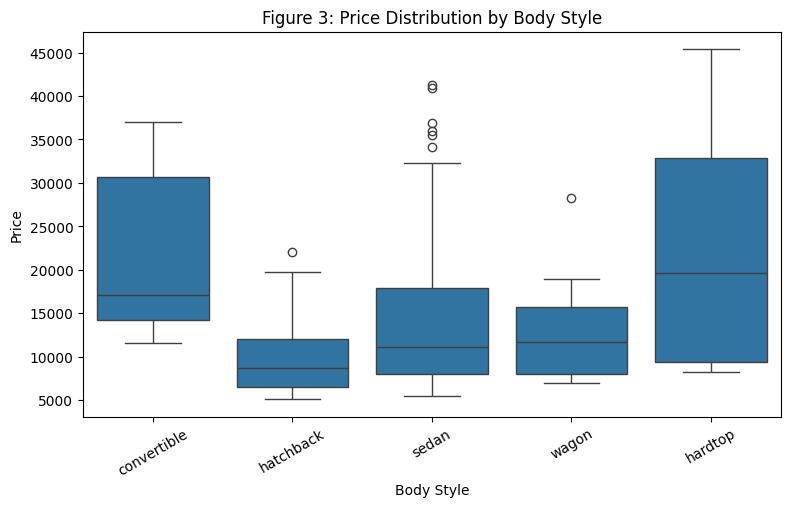

In [13]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="body-style", y="price")
plt.title("Figure 3: Price Distribution by Body Style")
plt.xlabel("Body Style")
plt.ylabel("Price")
plt.xticks(rotation=30)
plt.show()


## 14. EDA Visualization 4: Correlation Heatmap

The heatmap shows relationships among numerical variables. Strong positive or negative correlations help identify features related to car price.


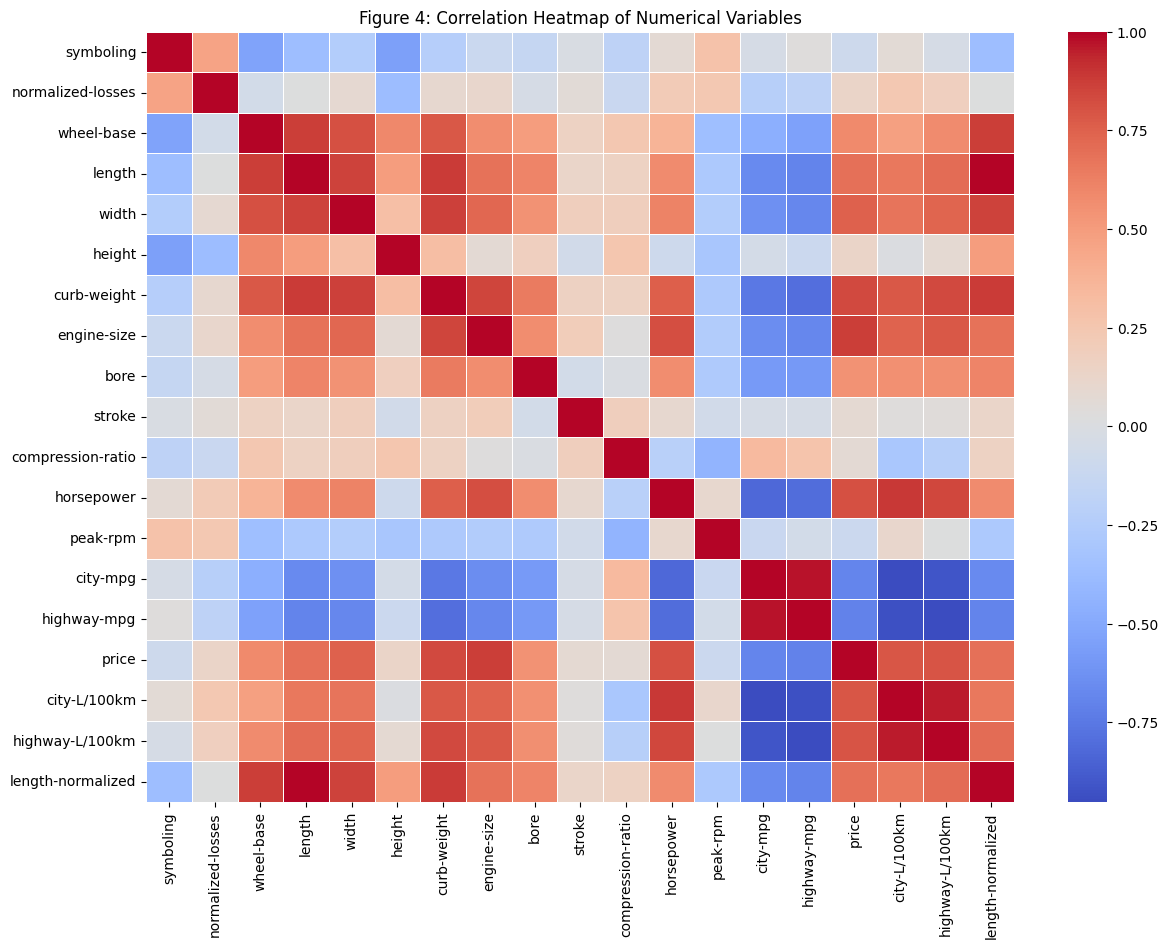

Correlation of numerical features with price:


,Correlation with Price
price,1.000
engine-size,0.872
curb-weight,0.834
horsepower,0.810
highway-L/100km,0.801
city-L/100km,0.790
width,0.751
length-normalized,0.691
length,0.691
wheel-base,0.585


In [14]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Figure 4: Correlation Heatmap of Numerical Variables")
plt.show()

# Show correlations with price in table form
price_correlations = numeric_df.corr()["price"].sort_values(ascending=False).round(3)
print("Correlation of numerical features with price:")
display(price_correlations.to_frame("Correlation with Price"))


## 15. Critical Thinking Checks for EDA

This section supports the brief questions:

- What features seem most related to price?
- Are there unusual patterns or outliers?
- Does higher horsepower always mean higher price?


Top numerical features most related to price by absolute correlation:


,Absolute Correlation with Price
engine-size,0.872
curb-weight,0.834
horsepower,0.810
highway-L/100km,0.801
city-L/100km,0.790
width,0.751
highway-mpg,0.705
length-normalized,0.691
length,0.691
city-mpg,0.687


Number of price outliers based on IQR: 14


,make,body-style,horsepower,engine-size,price
74,mercedes-benz,hardtop,184.0,304,45400.0
16,bmw,sedan,182.0,209,41315.0
73,mercedes-benz,sedan,184.0,308,40960.0
128,porsche,convertible,207.0,194,37028.0
17,bmw,sedan,182.0,209,36880.0
49,jaguar,sedan,262.0,326,36000.0
48,jaguar,sedan,176.0,258,35550.0
72,mercedes-benz,convertible,155.0,234,35056.0
71,mercedes-benz,sedan,155.0,234,34184.0
127,porsche,hardtop,207.0,194,34028.0


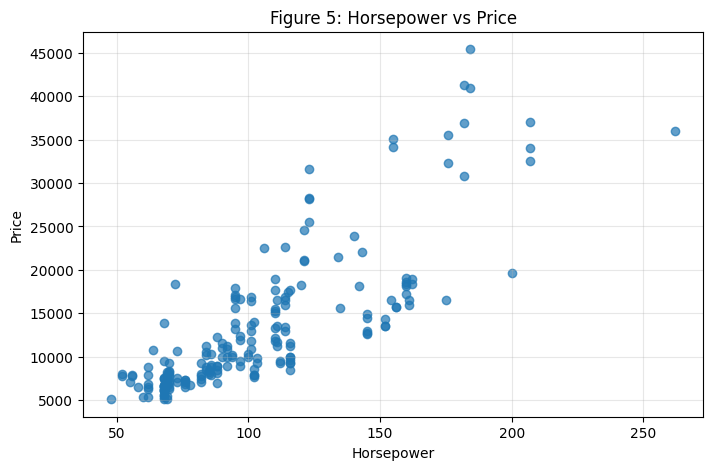

Observation support:
- A positive relationship is expected between horsepower and price, but it is not perfect.
- Some cars may have similar horsepower but different prices because price is also influenced by engine size, brand, body style, weight, fuel system and other features.


In [15]:
# Top numerical variables most related to price
top_price_correlations = price_correlations.drop("price").abs().sort_values(ascending=False).head(10)
print("Top numerical features most related to price by absolute correlation:")
display(top_price_correlations.to_frame("Absolute Correlation with Price"))

# Price outlier detection using IQR
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]
print(f"Number of price outliers based on IQR: {price_outliers.shape[0]}")
display(price_outliers[["make", "body-style", "horsepower", "engine-size", "price"]].sort_values("price", ascending=False).head(10))

# Scatter plot: horsepower and price
plt.figure(figsize=(8, 5))
plt.scatter(df["horsepower"], df["price"], alpha=0.7)
plt.title("Figure 5: Horsepower vs Price")
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.grid(alpha=0.3)
plt.show()

print("Observation support:")
print("- A positive relationship is expected between horsepower and price, but it is not perfect.")
print("- Some cars may have similar horsepower but different prices because price is also influenced by engine size, brand, body style, weight, fuel system and other features.")


# Task 3: Model Development — Regression

The objective is to predict car price as a continuous variable.

Models used:

1. Linear Regression  
2. Random Forest Regressor  
3. Split experiment: 80/20 and 70/30


## 16. Prepare Features for Regression

The model uses important numerical and categorical predictors. Categorical variables are converted into dummy variables.


In [16]:
# Selected features for regression
regression_features = [
    "horsepower",
    "engine-size",
    "curb-weight",
    "width",
    "city-L/100km",
    "drive-wheels",
    "body-style",
    "fuel-type",
    "aspiration",
    "engine-type"
]

# Prepare X and y
X_reg = df[regression_features].copy()
y_reg = df["price"].copy()

# One-hot encode categorical variables
X_reg_encoded = pd.get_dummies(X_reg, drop_first=True)

print("Regression feature matrix shape:", X_reg_encoded.shape)
display(X_reg_encoded.head())


Regression feature matrix shape: (201, 18)


,horsepower,engine-size,curb-weight,width,city-L/100km,drive-wheels_fwd,drive-wheels_rwd,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon,fuel-type_gas,aspiration_turbo,engine-type_l,engine-type_ohc,engine-type_ohcf,engine-type_ohcv,engine-type_rotor
0,111.0,130,2548,64.1,11.190476,False,True,False,False,False,False,True,False,False,False,False,False,False
1,111.0,130,2548,64.1,11.190476,False,True,False,False,False,False,True,False,False,False,False,False,False
2,154.0,152,2823,65.5,12.368421,False,True,False,True,False,False,True,False,False,False,False,True,False
3,102.0,109,2337,66.2,9.791667,True,False,False,False,True,False,True,False,False,True,False,False,False
4,115.0,136,2824,66.4,13.055556,False,False,False,False,True,False,True,False,False,True,False,False,False


## 17. Regression Evaluation Function

This function calculates R², MAE, MSE and RMSE for model comparison.


In [17]:
def evaluate_regression_model(model_name, y_true, y_pred):
    """Return common regression evaluation metrics."""
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return {
        "Model": model_name,
        "R2 Score": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    }


## 18. Linear Regression — 80/20 Split

The brief requires an 80% training and 20% testing split for Linear Regression.


In [18]:
# 80/20 train-test split
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X_reg_encoded,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Train Linear Regression model
linear_model_80 = LinearRegression()
linear_model_80.fit(X_train_80, y_train_80)

# Predict
linear_pred_80 = linear_model_80.predict(X_test_80)

# Evaluate
linear_80_results = evaluate_regression_model(
    "Linear Regression 80/20",
    y_test_80,
    linear_pred_80
)

display(pd.DataFrame([linear_80_results]).round(3))


,Model,R2 Score,MAE,MSE,RMSE
0,Linear Regression 80/20,0.819,3454.603,2.214905e+07,4706.278


## 19. Actual vs Predicted Price Plot — Linear Regression

This plot satisfies the model evaluation visualization requirement.


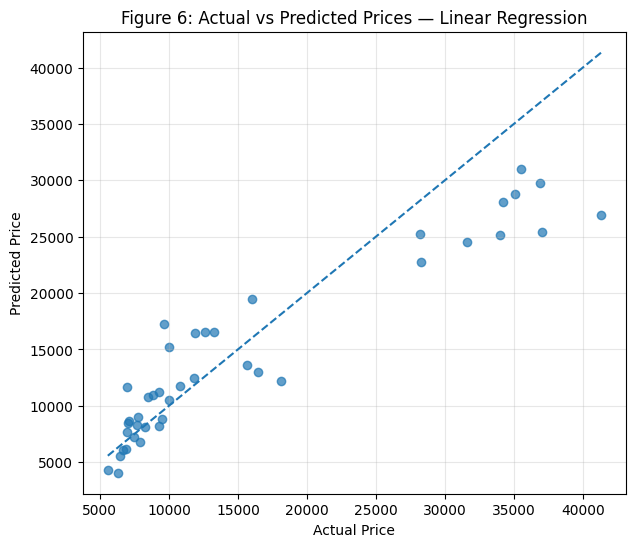

In [19]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test_80, linear_pred_80, alpha=0.7)
plt.plot([y_test_80.min(), y_test_80.max()], [y_test_80.min(), y_test_80.max()], linestyle="--")
plt.title("Figure 6: Actual vs Predicted Prices — Linear Regression")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid(alpha=0.3)
plt.show()


## 20. Random Forest Regressor — 80/20 Split

Random Forest is included as an additional model to compare with Linear Regression.


In [20]:
# Train Random Forest Regressor
rf_model_80 = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None
)

rf_model_80.fit(X_train_80, y_train_80)

# Predict
rf_pred_80 = rf_model_80.predict(X_test_80)

# Evaluate
rf_80_results = evaluate_regression_model(
    "Random Forest 80/20",
    y_test_80,
    rf_pred_80
)

display(pd.DataFrame([rf_80_results]).round(3))


,Model,R2 Score,MAE,MSE,RMSE
0,Random Forest 80/20,0.928,1912.106,8837284.107,2972.757


## 21. Actual vs Predicted Price Plot — Random Forest

This visualization compares actual prices with Random Forest predicted prices.


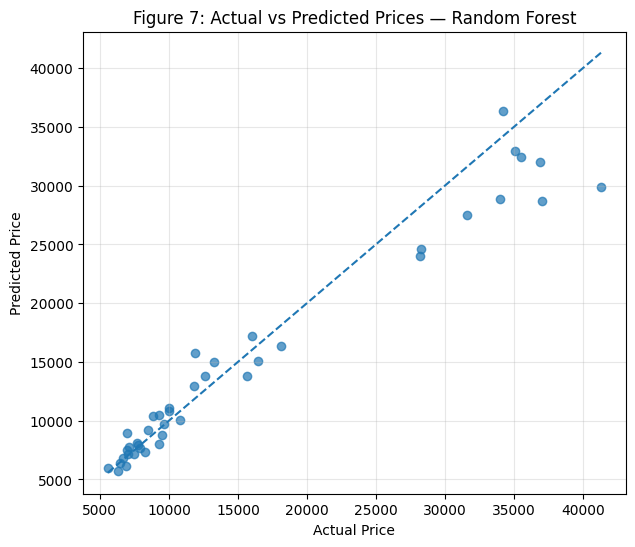

In [21]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test_80, rf_pred_80, alpha=0.7)
plt.plot([y_test_80.min(), y_test_80.max()], [y_test_80.min(), y_test_80.max()], linestyle="--")
plt.title("Figure 7: Actual vs Predicted Prices — Random Forest")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid(alpha=0.3)
plt.show()


## 22. Random Forest Feature Importance

Feature importance helps explain which variables contribute most to predicted car price.


,Feature,Importance
2,curb-weight,0.480579
1,engine-size,0.299894
0,horsepower,0.073973
4,city-L/100km,0.068775
3,width,0.053477
9,body-style_sedan,0.005704
6,drive-wheels_rwd,0.003150
16,engine-type_ohcv,0.002625
14,engine-type_ohc,0.002551
5,drive-wheels_fwd,0.002288


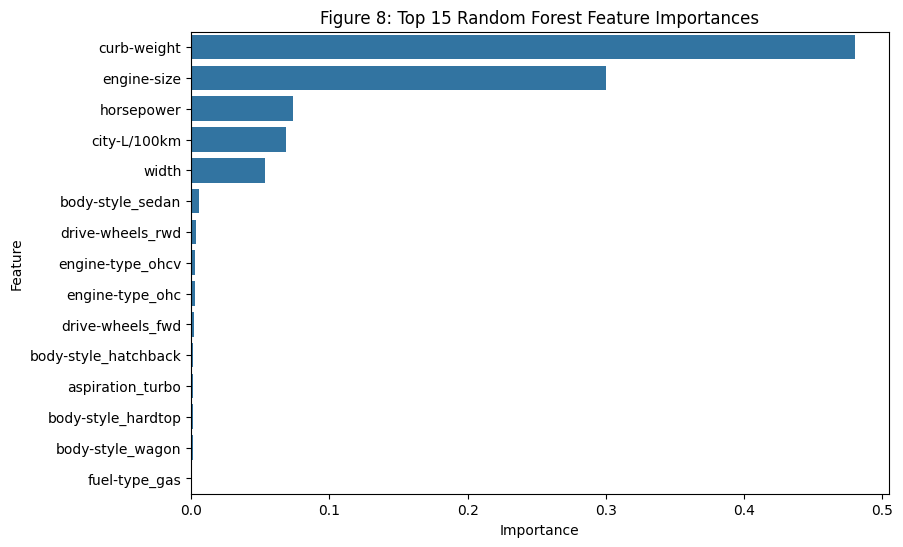

In [22]:
feature_importance = pd.DataFrame({
    "Feature": X_reg_encoded.columns,
    "Importance": rf_model_80.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance.head(15))

plt.figure(figsize=(9, 6))
sns.barplot(data=feature_importance.head(15), x="Importance", y="Feature")
plt.title("Figure 8: Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## 23. Experimentation: 80/20 vs 70/30 Splits

The brief states that experimentation is very important for MSc level. This section compares different train-test splits.


In [23]:
def run_regression_experiment(test_size, random_state=42):
    """Train Linear Regression and Random Forest using a selected test size."""
    X_train, X_test, y_train, y_test = train_test_split(
        X_reg_encoded,
        y_reg,
        test_size=test_size,
        random_state=random_state
    )

    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    lr_pred = lr.predict(X_test)

    # Random Forest
    rf = RandomForestRegressor(n_estimators=300, random_state=random_state)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)

    split_label = f"{int((1-test_size)*100)}/{int(test_size*100)}"

    results = [
        evaluate_regression_model(f"Linear Regression {split_label}", y_test, lr_pred),
        evaluate_regression_model(f"Random Forest {split_label}", y_test, rf_pred)
    ]

    return results

all_regression_results = []
all_regression_results.extend(run_regression_experiment(test_size=0.20))
all_regression_results.extend(run_regression_experiment(test_size=0.30))

regression_results_df = pd.DataFrame(all_regression_results).round(3)
display(regression_results_df.sort_values("R2 Score", ascending=False))


,Model,R2 Score,MAE,MSE,RMSE
1,Random Forest 80/20,0.928,1912.106,8.837284e+06,2972.757
3,Random Forest 70/30,0.920,1853.481,7.577034e+06,2752.641
2,Linear Regression 70/30,0.828,2874.421,1.625807e+07,4032.129
0,Linear Regression 80/20,0.819,3454.603,2.214905e+07,4706.278


## 24. Regression Model Comparison Visualization

This chart compares R² values for all regression experiments.


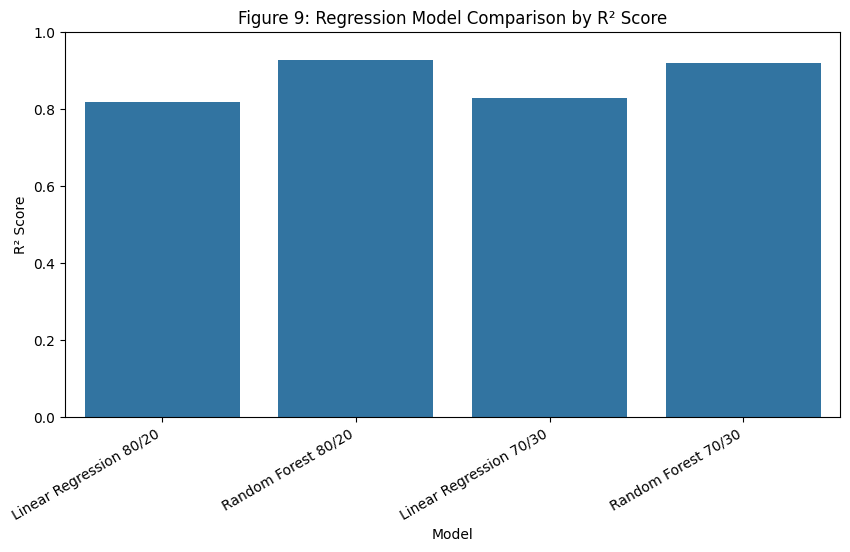

In [24]:
plt.figure(figsize=(10, 5))
sns.barplot(data=regression_results_df, x="Model", y="R2 Score")
plt.title("Figure 9: Regression Model Comparison by R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.show()


# Task 4: Classification Model

The price variable is converted into three categories:

- Low Price  
- Medium Price  
- High Price  

A Logistic Regression classifier is then trained and evaluated.


## 25. Create Price Categories

The brief requires using `pd.qcut()` to create three price groups.


In [25]:
df["price-category"] = pd.qcut(
    df["price"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print("Price category counts:")
display(df["price-category"].value_counts().to_frame("Count"))


Price category counts:


,Count
price-category,
Low,67
Medium,67
High,67


## 26. Prepare Classification Data

The same predictor variables are used. The target is now `price-category`.


In [26]:
X_clf = df[regression_features].copy()
y_clf = df["price-category"].copy()

# One-hot encode categorical variables
X_clf_encoded = pd.get_dummies(X_clf, drop_first=True)

# Stratified split keeps category distribution balanced in train and test sets
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf_encoded,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

print("Classification feature matrix shape:", X_clf_encoded.shape)
print("Training rows:", X_train_clf.shape[0])
print("Testing rows:", X_test_clf.shape[0])


Classification feature matrix shape: (201, 18)
Training rows: 160
Testing rows: 41


## 27. Train Logistic Regression Classification Model

Logistic Regression is trained using a pipeline with standard scaling.


In [27]:
# Build and train Logistic Regression model
logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42)
)

logistic_model.fit(X_train_clf, y_train_clf)

# Predictions
logistic_pred = logistic_model.predict(X_test_clf)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


## 28. Classification Evaluation

The brief requires Accuracy and Confusion Matrix.


In [28]:
# Accuracy
accuracy = accuracy_score(y_test_clf, logistic_pred)
print(f"Classification Accuracy: {accuracy:.3f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_clf, logistic_pred))

# Confusion matrix
labels = ["Low", "Medium", "High"]
cm = confusion_matrix(y_test_clf, logistic_pred, labels=labels)

cm_df = pd.DataFrame(cm, index=[f"Actual {x}" for x in labels], columns=[f"Predicted {x}" for x in labels])
display(cm_df)


Classification Accuracy: 0.902

Classification Report:
              precision    recall  f1-score   support

        High       0.87      1.00      0.93        13
         Low       0.93      0.93      0.93        14
      Medium       0.92      0.79      0.85        14

    accuracy                           0.90        41
   macro avg       0.90      0.90      0.90        41
weighted avg       0.90      0.90      0.90        41



,Predicted Low,Predicted Medium,Predicted High
Actual Low,13,1,0
Actual Medium,1,11,2
Actual High,0,0,13


## 29. Confusion Matrix Visualization

This chart shows where the model correctly or incorrectly classified cars into Low, Medium and High price groups.


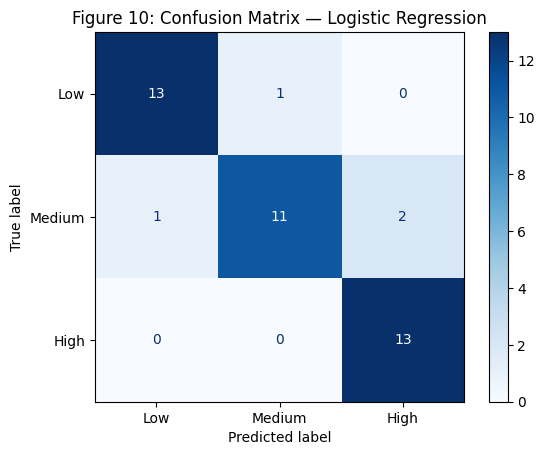

In [29]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Figure 10: Confusion Matrix — Logistic Regression")
plt.show()


# Task 6: Business Insights and Recommendations

The following code produces evidence for the business insight section of the report.


In [30]:
# Insight 1: Average price by body style
avg_price_body = df.groupby("body-style")["price"].mean().sort_values(ascending=False).round(2)
print("Average price by body style:")
display(avg_price_body.to_frame("Average Price"))

# Insight 2: Average price by drive wheels
avg_price_drive = df.groupby("drive-wheels")["price"].mean().sort_values(ascending=False).round(2)
print("\nAverage price by drive wheels:")
display(avg_price_drive.to_frame("Average Price"))

# Insight 3: Average price by horsepower bin
avg_price_hp_bin = df.groupby("horsepower-binned")["price"].mean().sort_values(ascending=False).round(2)
print("\nAverage price by horsepower category:")
display(avg_price_hp_bin.to_frame("Average Price"))

# Insight 4: Top numerical relationships with price
print("\nTop numerical correlations with price:")
display(price_correlations.drop("price").sort_values(ascending=False).head(10).to_frame("Correlation with Price"))

# Insight 5: Best regression model by R²
best_regression_model = regression_results_df.sort_values("R2 Score", ascending=False).iloc[0]
print("\nBest regression model based on R²:")
display(best_regression_model.to_frame("Value"))


Average price by body style:


,Average Price
body-style,
hardtop,22208.50
convertible,21890.50
sedan,14459.76
wagon,12371.96
hatchback,9957.44



Average price by drive wheels:


,Average Price
drive-wheels,
rwd,19757.61
4wd,10241.00
fwd,9244.78



Average price by horsepower category:


,Average Price
horsepower-binned,
High,31856.60
Medium,22486.47
Low,9989.75



Top numerical correlations with price:


,Correlation with Price
engine-size,0.872
curb-weight,0.834
horsepower,0.810
highway-L/100km,0.801
city-L/100km,0.790
width,0.751
length-normalized,0.691
length,0.691
wheel-base,0.585
bore,0.543



Best regression model based on R²:


,Value
Model,Random Forest 80/20
R2 Score,0.928
MAE,1912.106
MSE,8837284.107
RMSE,2972.757


## 30. Business Insight Write-Up Support

Use the outputs above to write your report. A suitable interpretation is:

- Cars with larger engine size, higher curb weight, greater width and stronger horsepower usually have higher prices.
- Fuel efficiency also matters because lower `city-mpg` means higher `city-L/100km`, which is often associated with larger and more powerful vehicles.
- Body style, drive wheels and engine type help explain price differences because they reflect vehicle design and performance class.
- Random Forest may perform better than Linear Regression if the relationship between vehicle features and price is complex and non-linear.
- Customers can use the model as a decision-support tool to estimate whether a car is reasonably priced.
- Companies can use the model to understand which features influence pricing and to support product positioning.


# Task 7: Conclusion Support

This section saves cleaned data and model results. These outputs can be used in the final report and presentation.


In [31]:
# Save cleaned dataset and model comparison results
df.to_csv("cleaned_auto_dataset.csv", index=False)
regression_results_df.to_csv("regression_model_comparison.csv", index=False)
feature_importance.to_csv("random_forest_feature_importance.csv", index=False)

print("Files saved:")
print("- cleaned_auto_dataset.csv")
print("- regression_model_comparison.csv")
print("- random_forest_feature_importance.csv")


Files saved:
- cleaned_auto_dataset.csv
- regression_model_comparison.csv
- random_forest_feature_importance.csv
